In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
os.chdir('/Users/samstephenson/Downloads/capy-bara')



import pipeline.calculate_metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gerrychain.grid
import random
from collections import deque
import warnings
pd.set_option('display.max_columns', None)
from itertools import combinations
from matplotlib.lines import Line2D


In [3]:
pd.set_option('display.max_colwidth', None)


In [4]:
#TODO: set total_x to black/black+white not black/totpop

In [5]:
black = pd.read_csv("outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv")
poc = pd.read_csv("outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_poc.csv")

In [6]:
#black = pd.read_csv("/Users/samstephenson/Desktop/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv")
#poc = pd.read_csv("/Users/samstephenson/Desktop/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_poc.csv")

In [7]:
poc["year"] = poc["filename"].str.extract(r"(\d{4})").astype(int)
black["year"] = black["filename"].str.extract(r"(\d{4})").astype(int)

In [8]:
black["poc_share"] = black["total_poc"] / (black["total_poc"] + black["total_white"])
black["black_share"] = black["total_black"] / (black["total_black"] + black["total_white"])

poc["poc_share"] = poc["total_poc"] / (poc["total_poc"] + poc["total_white"])
poc["black_share"] = poc["total_black"] / (poc["total_black"] + poc["total_white"])

In [9]:
black["cbsa_code"] = (
    black["filename"]
      .str.extract(r"tracts_in_cbsa_(\d+)")[0]
      .astype(int)
)

poc["cbsa_code"] = (
    poc["filename"]
      .str.extract(r"tracts_in_cbsa_(\d+)")[0]
      .astype(int)
)

In [10]:
#pick the 100 most populous metro areas
df_2020 = poc[poc["year"] == 2020]
df_2020 = df_2020.sort_values("total_population", ascending = False)
top_100 = df_2020.head(100)

In [11]:
black

,filename,x_col,y_col,tot_col,angle_1,angle_2,e_assort,he_assort,skew_self_0,skew_other_0,edge_0,skew'_self_0,skew'_other_0,half_edge_0,skew_self_exact_0,skew_other_exact_0,edge_exact_0,skew'_self_exact_0,skew'_other_exact_0,half_edge_exact_0,skew_self_0.5,skew_other_0.5,edge_0.5,skew'_self_0.5,skew'_other_0.5,half_edge_0.5,skew_self_exact_0.5,skew_other_exact_0.5,edge_exact_0.5,skew'_self_exact_0.5,skew'_other_exact_0.5,half_edge_exact_0.5,skew_self_1,skew_other_1,edge_1,skew'_self_1,skew'_other_1,half_edge_1,skew_self_exact_1,skew_other_exact_1,edge_exact_1,skew'_self_exact_1,skew'_other_exact_1,half_edge_exact_1,skew_self_2,skew_other_2,edge_2,skew'_self_2,skew'_other_2,half_edge_2,skew_self_exact_2,skew_other_exact_2,edge_exact_2,skew'_self_exact_2,skew'_other_exact_2,half_edge_exact_2,skew_self_10,skew_other_10,edge_10,skew'_self_10,skew'_other_10,half_edge_10,skew_self_exact_10,skew_other_exact_10,edge_exact_10,skew'_self_exact_10,skew'_other_exact_10,half_edge_exact_10,skew_self_lim,skew_other_lim,edge_lim,skew'_self_lim,skew'_other_lim,half_edge_lim,skew_self_exact_lim,skew_other_exact_lim,edge_exact_lim,skew'_self_exact_lim,skew'_other_exact_lim,half_edge_exact_lim,dissimilarity_1,dissimilarity_2,dissimilarity_10,frey,gini,moran_A,moran_P,moran_L,moran_M,moran_D_1,moran_D_2,total_population,total_white,total_poc,total_black,total_x,total_y,total_nodes,total_edges,year,poc_share,black_share,cbsa_code
0,study_areas/2020/tracts_in_cbsa_33140_2020_march_2020_vintage_connected.json,BLACK,WHITE,TOTPOP,172042794,8.599694e+07,NaN,NaN,0.112888,0.820192,0.466540,0.202875,0.901215,0.552045,0.112888,0.820192,0.466540,0.202875,0.901215,0.552045,0.119769,0.823809,0.471789,0.213917,0.903394,0.558655,0.119769,0.823809,0.471789,0.213917,0.903394,0.558655,0.125560,0.826785,0.476172,0.223107,0.905180,0.564144,0.125560,0.826785,0.476172,0.223107,0.905180,0.564144,0.134769,0.831392,0.483080,0.237526,0.907934,0.572730,0.134769,0.831392,0.483080,0.237526,0.907934,0.572730,0.165156,0.845586,0.505371,0.283492,0.916333,0.599913,0.165156,0.845586,0.505371,0.283492,0.916333,0.599913,0.192956,0.857363,0.525160,0.323493,0.923205,0.623349,0.192956,0.857363,0.525160,0.323493,0.923205,0.623349,0.598640,0.196050,0.123206,0.598640,0.732310,0.368640,0.332288,0.361483,0.409247,-0.034450,0.244528,112417,85957,26460,11874,0.105625,0.764626,30,73,2020,0.235374,0.121373,33140
1,study_areas/2020/tracts_in_cbsa_42700_2020_march_2020_vintage_connected.json,BLACK,WHITE,TOTPOP,108942272,5.445239e+07,0.480769,0.490196,0.077016,0.794131,0.435573,0.143017,0.885254,0.514135,0.077016,0.794131,0.435573,0.143017,0.885254,0.514135,0.082052,0.797691,0.439871,0.151659,0.887462,0.519561,0.082052,0.797691,0.439871,0.151659,0.887462,0.519561,0.086223,0.800576,0.443399,0.158757,0.889244,0.524001,0.086223,0.800576,0.443399,0.158757,0.889244,0.524001,0.092730,0.804967,0.448848,0.169722,0.891946,0.530834,0.092730,0.804967,0.448848,0.169722,0.891946,0.530834,0.113177,0.817944,0.465561,0.203341,0.899856,0.551599,0.113177,0.817944,0.465561,0.203341,0.899856,0.551599,0.130612,0.828121,0.479366,0.231046,0.905980,0.568513,0.130612,0.828121,0.479366,0.231046,0.905980,0.568513,0.420530,0.145157,0.110671,0.420530,0.563374,0.185038,0.197957,0.425689,0.339179,-0.031311,0.148359,101235,65511,35724,9484,0.093683,0.647118,33,78,2020,0.352882,0.126462,42700
2,study_areas/2020/tracts_in_cbsa_14540_2020_march_2020_vintage_connected.json,BLACK,WHITE,TOTPOP,281234712,1.405792e+08,0.529481,0.594038,0.079885,0.836023,0.457954,0.147951,0.910689,0.529320,0.079885,0.836023,0.457954,0.147951,0.910689,0.529320,0.081783,0.838945,0.460364,0.151201,0.912420,0.531811,0.081783,0.838945,0.460364,0.151201,0.912420,0.531811,0.083387,0.841343,0.462365,0.153937,0.913836,0.533887,0.083387,0.841343,0.462365,0.153937,0.913836,0.533887,0.085947,0.845043,0.465495,0.158290,0.916015,0.537152,0.085947,0.845043,0.465495,0.158290,0.916015,0.537152,0.094491,0.856359,0.475425,0.172666,0.922622,0.547644,0.094491,0.856359,0.4754

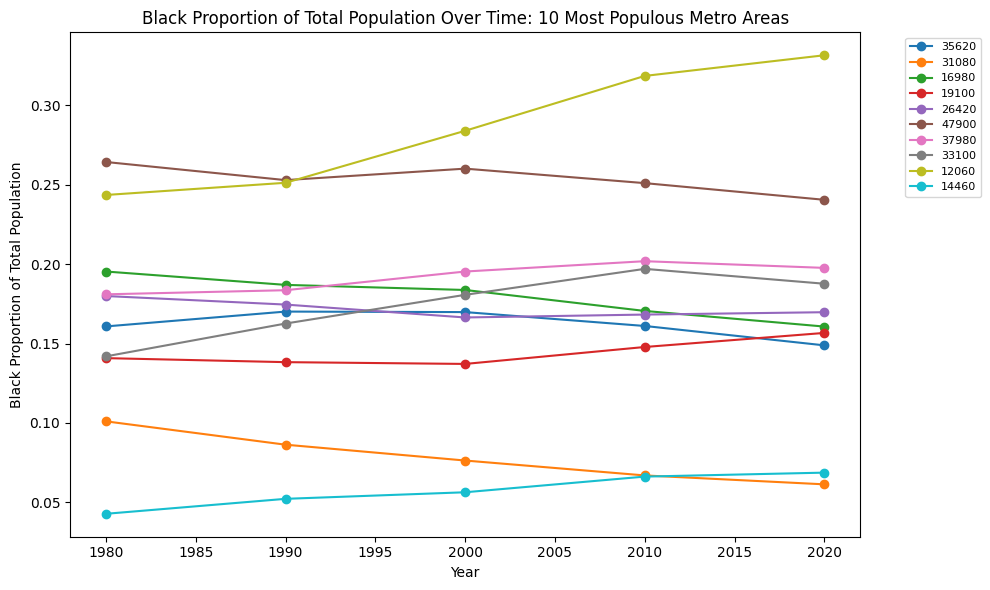

In [39]:
# get top 10 most populous metros from 2020 data
top10_cbsa = (
    black[black["year"] == 2020]
    .sort_values("total_population", ascending=False)
    .head(10)["cbsa_code"]
    .tolist()
)

# optional: add names if you know them
name_map = {cbsa: str(cbsa) for cbsa in top10_cbsa}  # swap in real names if you have them

# filter to those metros across all years
plot_df = black[black["cbsa_code"].isin(top10_cbsa)].sort_values("year")

fig, ax = plt.subplots(figsize=(10, 6))

for cbsa in top10_cbsa:
    city_df = plot_df[plot_df["cbsa_code"] == cbsa]
    ax.plot(city_df["year"], city_df["total_x"], marker="o", label=name_map[cbsa])

ax.set_xlabel("Year")
ax.set_ylabel("Black Proportion of Total Population")
ax.set_title("Black Proportion of Total Population Over Time: 10 Most Populous Metro Areas")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [13]:
top10_cbsa = (
    black[black["year"] == 2020]
    .sort_values("total_population", ascending=False)
    .head(10)["cbsa_code"]
    .tolist()
)

plot_df = black[black["cbsa_code"].isin(top10_cbsa)]

share_1980 = plot_df[plot_df["year"] == 1980].set_index("cbsa_code")["total_x"]
share_2020 = plot_df[plot_df["year"] == 2020].set_index("cbsa_code")["total_x"]

diff = (share_2020 - share_1980).rename("black_share_change").reset_index()
diff = diff.sort_values("black_share_change", ascending=False)
print(diff)

   cbsa_code  black_share_change
0      12060            0.087985
6      33100            0.045735
1      14460            0.025921
8      37980            0.016649
3      19100            0.015877
4      26420           -0.010190
7      35620           -0.011925
9      47900           -0.023807
2      16980           -0.034669
5      31080           -0.039672


In [14]:
top10_cbsa = (
    black[black["year"] == 2020]
    .sort_values("total_population", ascending=False)
    .head(10)["cbsa_code"]
    .tolist()
)

plot_df = black[black["cbsa_code"].isin(top10_cbsa)]

share_1980 = plot_df[plot_df["year"] == 2000].set_index("cbsa_code")["black_share"]
share_2020 = plot_df[plot_df["year"] == 2020].set_index("cbsa_code")["black_share"]

diff = (share_2020 - share_1980).rename("black_share_change").reset_index()
diff = diff.sort_values("black_share_change", ascending=False)
print(diff)

   cbsa_code  black_share_change
0      12060            0.111613
6      33100            0.101308
3      19100            0.079338
4      26420            0.077901
9      47900            0.043565
8      37980            0.033952
1      14460            0.028252
7      35620            0.014908
2      16980            0.006142
5      31080            0.001103


In [15]:


#first pick (w/out replacement) the 40 most populous, then pick 60 most diverse
#df_2010 = poc[poc["year"]==2010]
#calculate diversity
#df_2010["blau"] = 1 - ((df_2010["total_black"] / df_2010["total_population"])**2 +
#                        (df_2010["total_white"] / df_2010["total_population"])**2 +
#                        (df_2010["total_asian"] / df_2010["total_population"])**2 +
#                        (df_2010["total_amin"] / df_2010["total_population"])**2 +
#                        (df_2010["total_population"] - (df_2010["total_black"] + df_2010["total_white"] + df_2010["total_asian"] + df_2010["total_amin"])/ df_2010["total_population"])**2
#                        )

#pick forty most populous cities
#df_2010 = df_2010.sort_values("total_population",  ascending = False)
#top_40 = df_2010.head(40)
#df_2010_dropped = df_2010.iloc[40:].reset_index(drop=True)

#pick the 60 most diverse cities not in the 40 most populous
#df_2010 = df_2010_dropped.sort_values("blau", ascending = False)
#top_60 = df_2010_dropped.head(60)

#combine
#top_100 = pd.concat([top_40, top_60], ignore_index=True)

Fig 7.

In [16]:
pd.set_option('display.max_columns', None)

In [17]:
name_map = {
    14460: "Boston",
    16980: "Chicago",
    19820: "Detroit",
    35620: "NYC",
    29820: "Las Vegas",
}

In [18]:
cities_big = [
    (14460, "Boston"),
    (16980, "Chicago"),
    (19820, "Detroit"),
    (35620, "NYC"),
    (29820, "Las Vegas")
    ]

In [19]:
for city in cities_big:
    n = len(poc[poc["cbsa_code"] == city[0]])
    print(city, n)

(14460, 'Boston') 5
(16980, 'Chicago') 5
(19820, 'Detroit') 5
(35620, 'NYC') 5
(29820, 'Las Vegas') 5


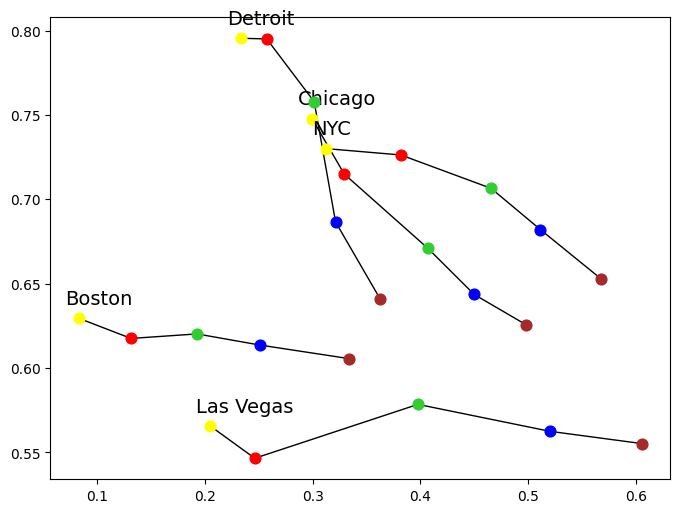

In [20]:
colors = {
    1970: "purple",
    1980: "yellow",
    1990: "red",
    2000: "limegreen",
    2010: "blue",
    2020: "brown"
}

fig, ax = plt.subplots(figsize=(8, 6))

for city in cities_big:
    city_df = (
        poc[poc["cbsa_code"] == city[0]]
        .sort_values("year")
    )

    x = city_df["total_x"]
    y = city_df["half_edge_1"]

    # connect years
    ax.plot(x, y, color="black", lw=1)

    # plot points
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            s=60,
            zorder=3
        )
    
    # label city near first point
    first = city_df.iloc[0]
    ax.annotate(
        city[1],
        (first["total_x"], first["half_edge_1"]),
        xytext=(-10, 10),
        textcoords="offset points",
        fontsize=14
    )



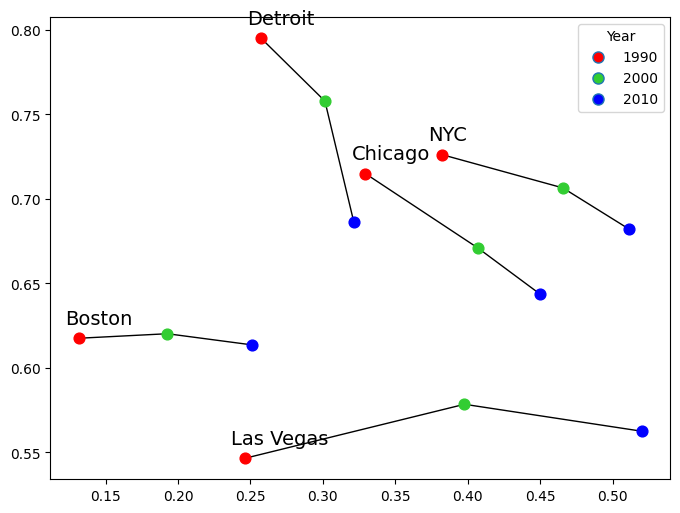

In [21]:
cities_big = [
    (14460, "Boston"),
    (16980, "Chicago"),
    (19820, "Detroit"),
    (35620, "NYC"),
    (29820, "Las Vegas")
    ]

colors = {
    1990: "red",
    2000: "limegreen",
    2010: "blue",
}

fig, ax = plt.subplots(figsize=(8, 6))

for city in cities_big:
    city_df = (
        poc[poc["cbsa_code"] == city[0]]
    )
    city_df = (
        city_df[city_df["year"].isin((1990, 2000, 2010))]
        .sort_values("year")
    )

    x = city_df["total_x"]
    y = city_df["half_edge_1"]

    # connect years
    ax.plot(x, y, color="black", lw=1)

    # plot points
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            s=60,
            zorder=3
        )
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            label=str(year),
            markerfacecolor=color,
            markersize=8
        )
        for year, color in colors.items()
    ]

    ax.legend(handles=legend_elements, title="Year")

    # label city near first point
    first = city_df.iloc[0]
    ax.annotate(
        city[1],
        (first["total_x"], first["half_edge_1"]),
        xytext=(-10, 10),
        textcoords="offset points",
        fontsize=14
    )

In [22]:
cities_small = [
    (33340, "Milwaukee"),
    (13820, "Birmingham"),
    (22420, "Flint"),
    (35300, "New Haven"),
    (43780, "South Bend")
    ]

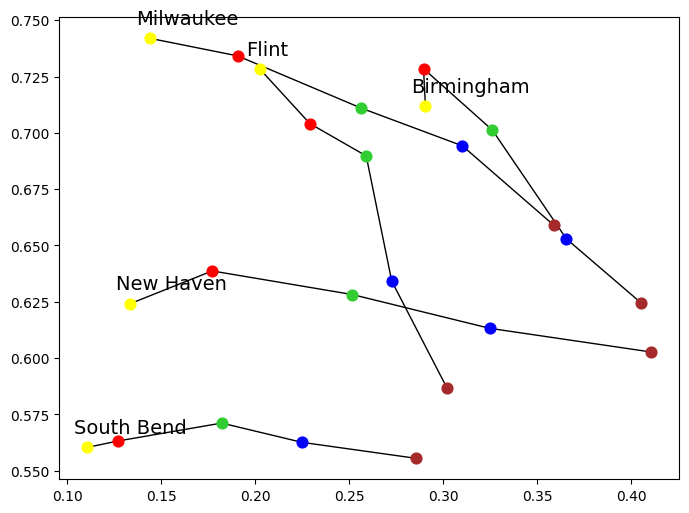

In [23]:
colors = {
    1970: "purple",
    1980: "yellow",
    1990: "red",
    2000: "limegreen",
    2010: "blue",
    2020: "brown"
}

fig, ax = plt.subplots(figsize=(8, 6))

for city in cities_small:
    city_df = (
        poc[poc["cbsa_code"] == city[0]]
        .sort_values("year")
    )

    x = city_df["total_x"]
    y = city_df["half_edge_1"]

    # connect years
    ax.plot(x, y, color="black", lw=1)

    # plot points
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            s=60,
            zorder=3
        )
    
    # label city near first point
    first = city_df.iloc[0]
    ax.annotate(
        city[1],
        (first["total_x"], first["half_edge_1"]),
        xytext=(-10, 10),
        textcoords="offset points",
        fontsize=14
    )


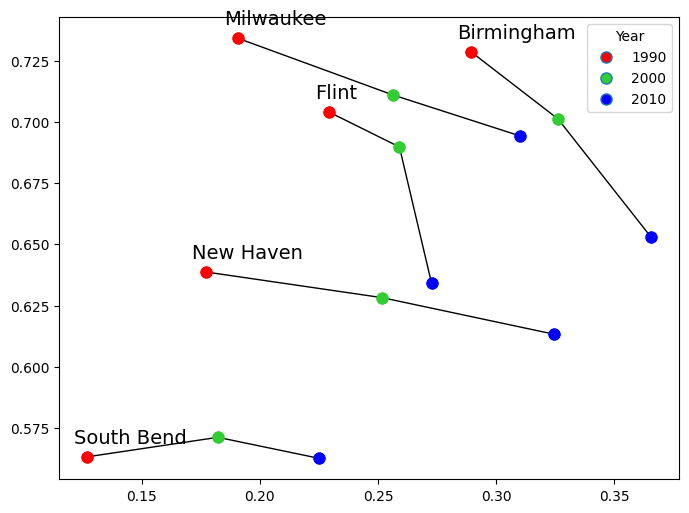

In [24]:
cities_small = [
    (33340, "Milwaukee"),
    (13820, "Birmingham"),
    (22420, "Flint"),
    (35300, "New Haven"),
    (43780, "South Bend")
    ]

colors = {
    1990: "red",
    2000: "limegreen",
    2010: "blue",
}

fig, ax = plt.subplots(figsize=(8, 6))

for city in cities_small:
    city_df = (
        poc[poc["cbsa_code"] == city[0]]
    )
    city_df = (
        city_df[city_df["year"].isin((1990, 2000, 2010))]
        .sort_values("year")
    )

    x = city_df["total_x"]
    y = city_df["half_edge_1"]

    # connect years
    ax.plot(x, y, color="black", lw=1)

    # plot points
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            label = colors[row["year"]],
            s=60,
            zorder=3
        )
    
    for _, row in city_df.iterrows():
        ax.scatter(
            row["total_x"],
            row["half_edge_1"],
            color=colors[row["year"]],
            s=60,
            zorder=3
        )
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            label=str(year),
            markerfacecolor=color,
            markersize=8
        )
        for year, color in colors.items()
    ]

    ax.legend(handles=legend_elements, title="Year")

    # label city near first point
    first = city_df.iloc[0]
    ax.annotate(
        city[1],
        (first["total_x"], first["half_edge_1"]),
        xytext=(-10, 10),
        textcoords="offset points",
        fontsize=14
    )

Fig 8.

In [25]:
def rankr(x_score, y_score, label_x = None, label_y = None, best_fit = True, df = top_100):
    if label_x == None:
        label_x = x_score
    if label_y == None:
        label_y = y_score   

    y = df[[y_score, "cbsa_code"]].sort_values(y_score)
    y.sort_values(y_score, inplace = True)

    x = df[[x_score, "cbsa_code"]].sort_values(x_score)
    x.sort_values(x_score, inplace = True)

    x = x.reset_index(drop=True)
    x["rank_x"] = np.arange(1, len(x) + 1)

    # y is already sorted by score 2
    y = y.reset_index(drop=True)
    y["rank_y"] = np.arange(1, len(y) + 1)

    # keep only cbsa and ranks
    ranks = x[["cbsa_code", "rank_x"]].merge(
        y[["cbsa_code", "rank_y"]],
        on="cbsa_code"
        )

    # fit line y = mx + b
    m, b = np.polyfit(ranks["rank_x"], ranks["rank_y"], 1)

    # scatterplot   
    plt.scatter(ranks["rank_x"], ranks["rank_y"])

    # best-fit line
    if best_fit == True:
        x_line = np.linspace(ranks["rank_x"].min(), ranks["rank_x"].max(), 100)
        plt.plot(x_line, m * x_line + b)

    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.show()

In [26]:
black

,filename,x_col,y_col,tot_col,angle_1,angle_2,e_assort,he_assort,skew_self_0,skew_other_0,edge_0,skew'_self_0,skew'_other_0,half_edge_0,skew_self_exact_0,skew_other_exact_0,edge_exact_0,skew'_self_exact_0,skew'_other_exact_0,half_edge_exact_0,skew_self_0.5,skew_other_0.5,edge_0.5,skew'_self_0.5,skew'_other_0.5,half_edge_0.5,skew_self_exact_0.5,skew_other_exact_0.5,edge_exact_0.5,skew'_self_exact_0.5,skew'_other_exact_0.5,half_edge_exact_0.5,skew_self_1,skew_other_1,edge_1,skew'_self_1,skew'_other_1,half_edge_1,skew_self_exact_1,skew_other_exact_1,edge_exact_1,skew'_self_exact_1,skew'_other_exact_1,half_edge_exact_1,skew_self_2,skew_other_2,edge_2,skew'_self_2,skew'_other_2,half_edge_2,skew_self_exact_2,skew_other_exact_2,edge_exact_2,skew'_self_exact_2,skew'_other_exact_2,half_edge_exact_2,skew_self_10,skew_other_10,edge_10,skew'_self_10,skew'_other_10,half_edge_10,skew_self_exact_10,skew_other_exact_10,edge_exact_10,skew'_self_exact_10,skew'_other_exact_10,half_edge_exact_10,skew_self_lim,skew_other_lim,edge_lim,skew'_self_lim,skew'_other_lim,half_edge_lim,skew_self_exact_lim,skew_other_exact_lim,edge_exact_lim,skew'_self_exact_lim,skew'_other_exact_lim,half_edge_exact_lim,dissimilarity_1,dissimilarity_2,dissimilarity_10,frey,gini,moran_A,moran_P,moran_L,moran_M,moran_D_1,moran_D_2,total_population,total_white,total_poc,total_black,total_x,total_y,total_nodes,total_edges,year,poc_share,black_share,cbsa_code
0,study_areas/2020/tracts_in_cbsa_33140_2020_march_2020_vintage_connected.json,BLACK,WHITE,TOTPOP,172042794,8.599694e+07,NaN,NaN,0.112888,0.820192,0.466540,0.202875,0.901215,0.552045,0.112888,0.820192,0.466540,0.202875,0.901215,0.552045,0.119769,0.823809,0.471789,0.213917,0.903394,0.558655,0.119769,0.823809,0.471789,0.213917,0.903394,0.558655,0.125560,0.826785,0.476172,0.223107,0.905180,0.564144,0.125560,0.826785,0.476172,0.223107,0.905180,0.564144,0.134769,0.831392,0.483080,0.237526,0.907934,0.572730,0.134769,0.831392,0.483080,0.237526,0.907934,0.572730,0.165156,0.845586,0.505371,0.283492,0.916333,0.599913,0.165156,0.845586,0.505371,0.283492,0.916333,0.599913,0.192956,0.857363,0.525160,0.323493,0.923205,0.623349,0.192956,0.857363,0.525160,0.323493,0.923205,0.623349,0.598640,0.196050,0.123206,0.598640,0.732310,0.368640,0.332288,0.361483,0.409247,-0.034450,0.244528,112417,85957,26460,11874,0.105625,0.764626,30,73,2020,0.235374,0.121373,33140
1,study_areas/2020/tracts_in_cbsa_42700_2020_march_2020_vintage_connected.json,BLACK,WHITE,TOTPOP,108942272,5.445239e+07,0.480769,0.490196,0.077016,0.794131,0.435573,0.143017,0.885254,0.514135,0.077016,0.794131,0.435573,0.143017,0.885254,0.514135,0.082052,0.797691,0.439871,0.151659,0.887462,0.519561,0.082052,0.797691,0.439871,0.151659,0.887462,0.519561,0.086223,0.800576,0.443399,0.158757,0.889244,0.524001,0.086223,0.800576,0.443399,0.158757,0.889244,0.524001,0.092730,0.804967,0.448848,0.169722,0.891946,0.530834,0.092730,0.804967,0.448848,0.169722,0.891946,0.530834,0.113177,0.817944,0.465561,0.203341,0.899856,0.551599,0.113177,0.817944,0.465561,0.203341,0.899856,0.551599,0.130612,0.828121,0.479366,0.231046,0.905980,0.568513,0.130612,0.828121,0.479366,0.231046,0.905980,0.568513,0.420530,0.145157,0.110671,0.420530,0.563374,0.185038,0.197957,0.425689,0.339179,-0.031311,0.148359,101235,65511,35724,9484,0.093683,0.647118,33,78,2020,0.352882,0.126462,42700
2,study_areas/2020/tracts_in_cbsa_14540_2020_march_2020_vintage_connected.json,BLACK,WHITE,TOTPOP,281234712,1.405792e+08,0.529481,0.594038,0.079885,0.836023,0.457954,0.147951,0.910689,0.529320,0.079885,0.836023,0.457954,0.147951,0.910689,0.529320,0.081783,0.838945,0.460364,0.151201,0.912420,0.531811,0.081783,0.838945,0.460364,0.151201,0.912420,0.531811,0.083387,0.841343,0.462365,0.153937,0.913836,0.533887,0.083387,0.841343,0.462365,0.153937,0.913836,0.533887,0.085947,0.845043,0.465495,0.158290,0.916015,0.537152,0.085947,0.845043,0.465495,0.158290,0.916015,0.537152,0.094491,0.856359,0.475425,0.172666,0.922622,0.547644,0.094491,0.856359,0.4754

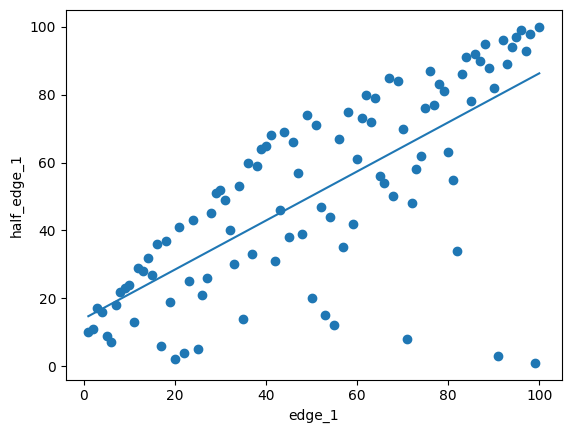

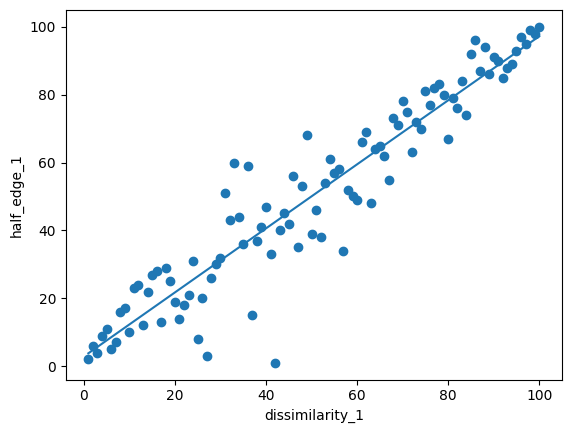

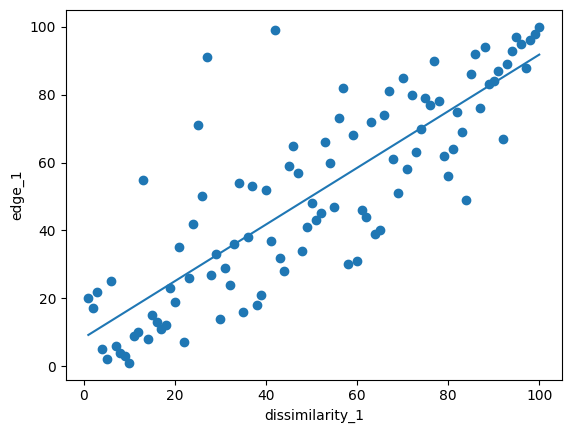

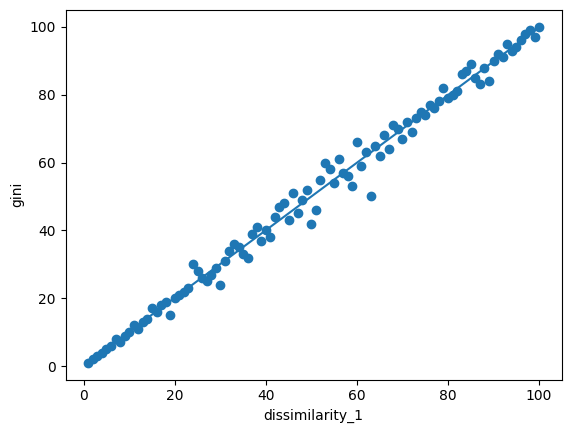

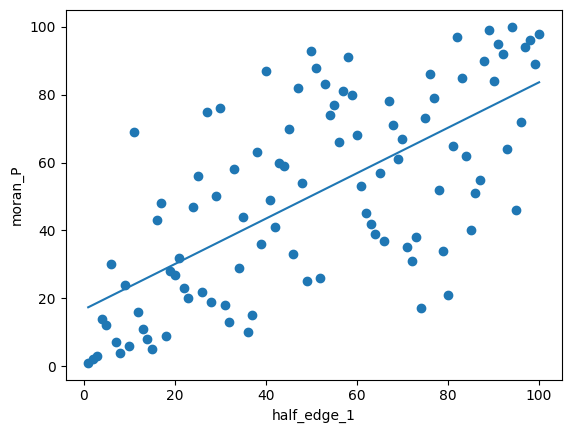

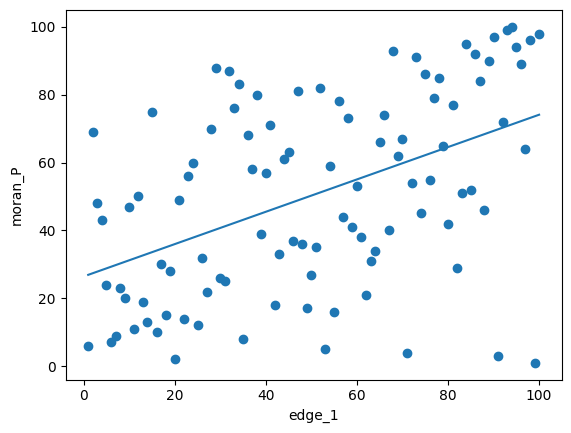

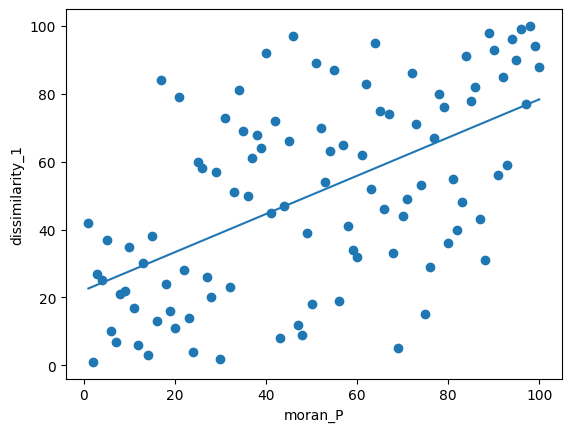

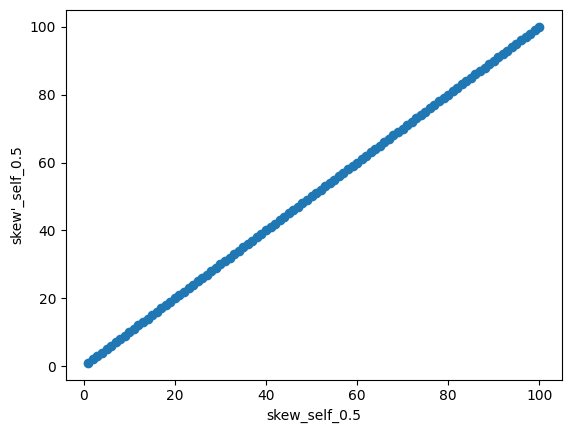

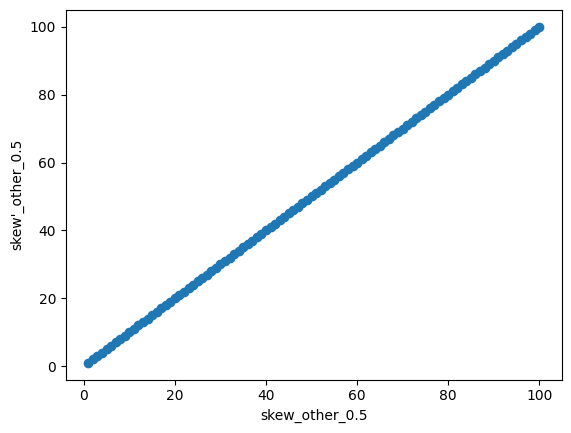

In [27]:
score_pairs = [("edge_1", "half_edge_1"), 
               ("dissimilarity_1", "half_edge_1"),
               ("dissimilarity_1", "edge_1"),
               ("dissimilarity_1", "gini"),
               ("half_edge_1", "moran_P"),
               ("edge_1", "moran_P"),
               ("moran_P", "dissimilarity_1"),
               ("skew_self_0.5", "skew'_self_0.5"),
               ("skew_other_0.5", "skew'_other_0.5")]

for pair in score_pairs:
    rankr(pair[0], pair[1])

Fig 10

In [28]:
def plotr(x_var, y_var, label_x = None, label_y = None, df = top_100):
    if label_x == None:
        label_x = x_var
    if label_y == None:
        label_y = y_var 

    # scatterplot   
    plt.scatter(df[x_var], df[y_var])

    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.show()
    

In [29]:
small_pop = top_100[top_100["total_population"] <= 1800000]

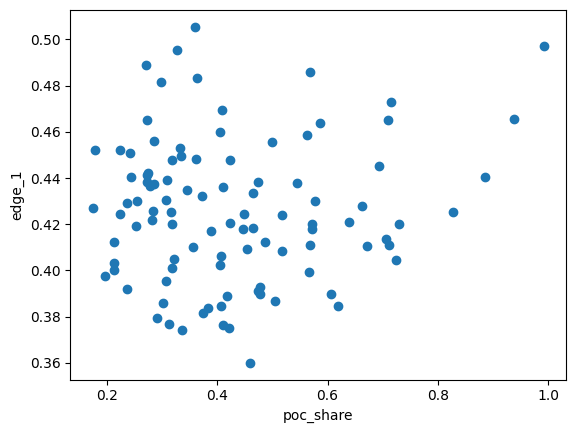

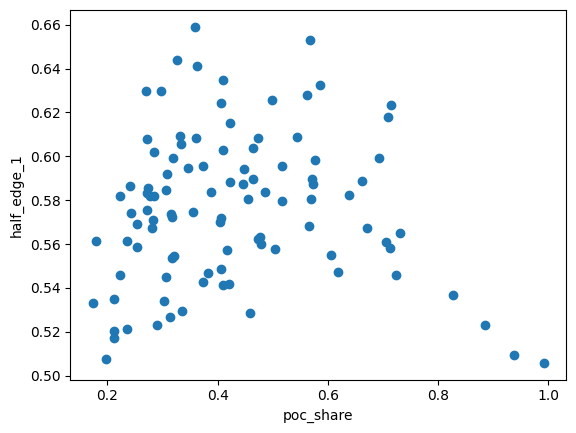

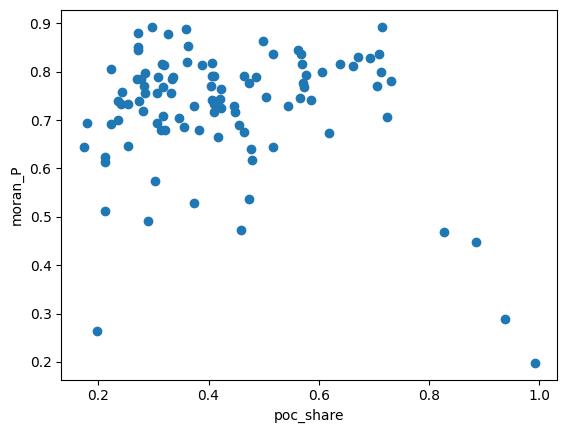

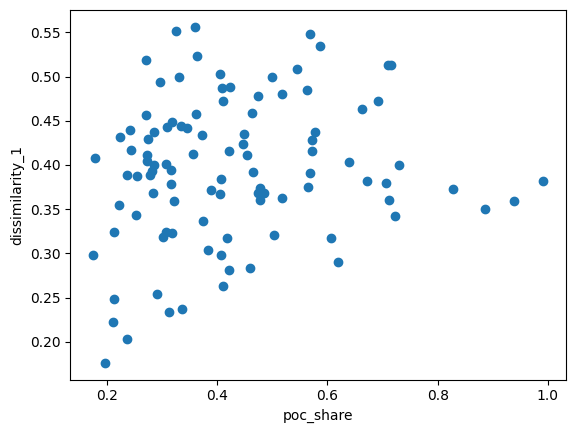

In [30]:
scores = ["edge_1", "half_edge_1", "moran_P", "dissimilarity_1"]

for score in scores:
    plotr("poc_share", score)

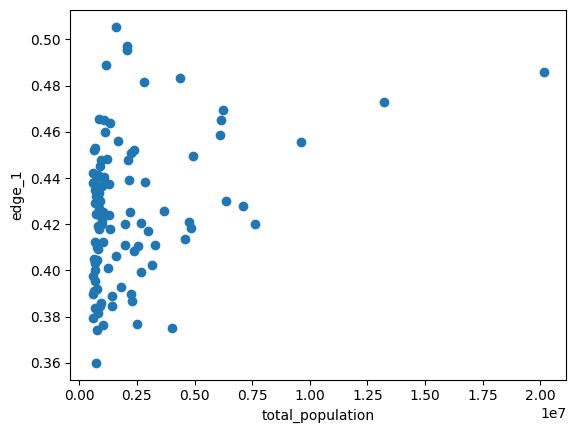

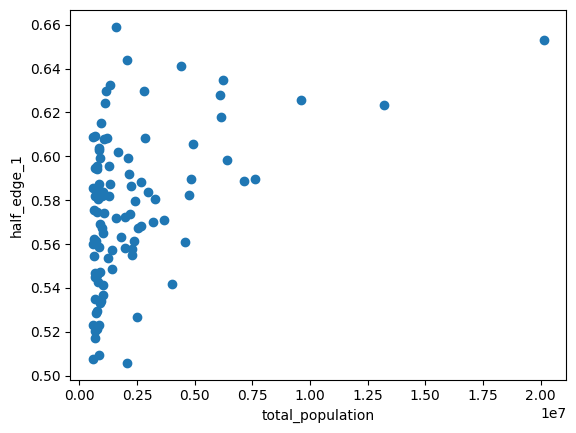

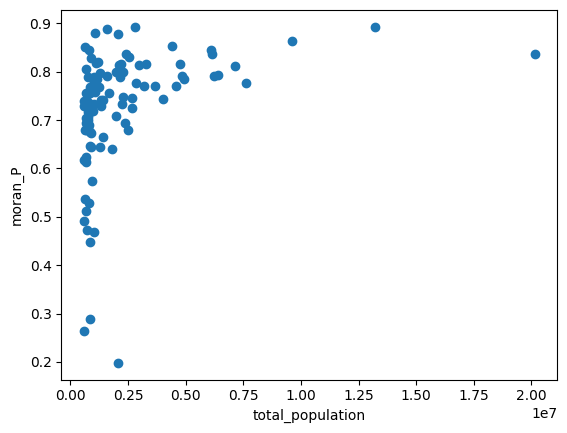

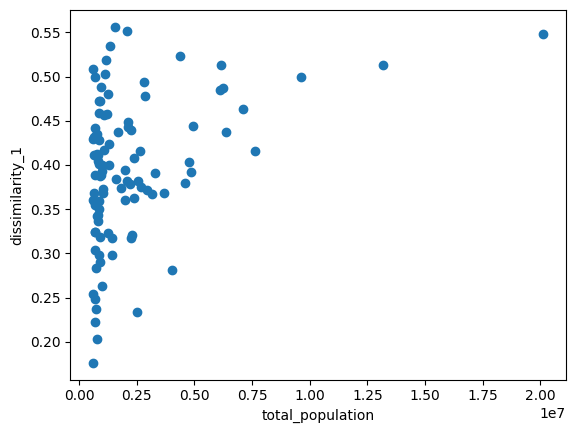

In [31]:
scores = ["edge_1", "half_edge_1", "moran_P", "dissimilarity_1"]

for score in scores:
    plotr("total_population", score)

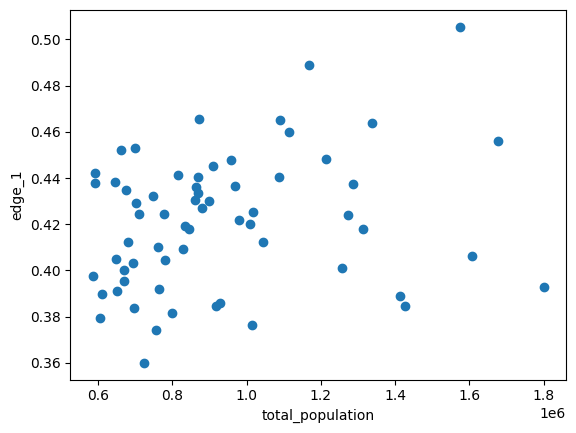

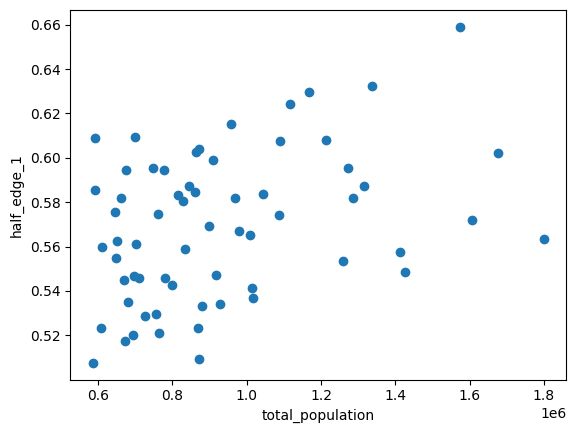

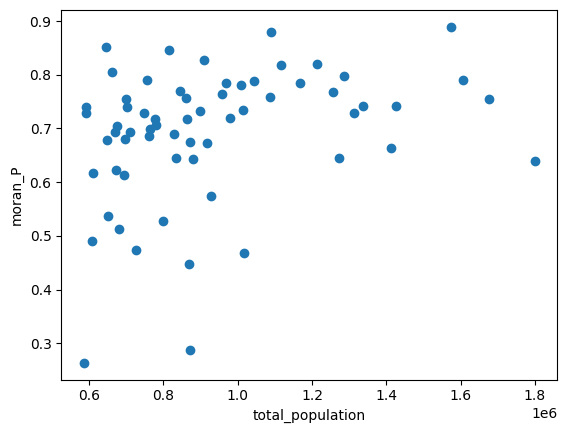

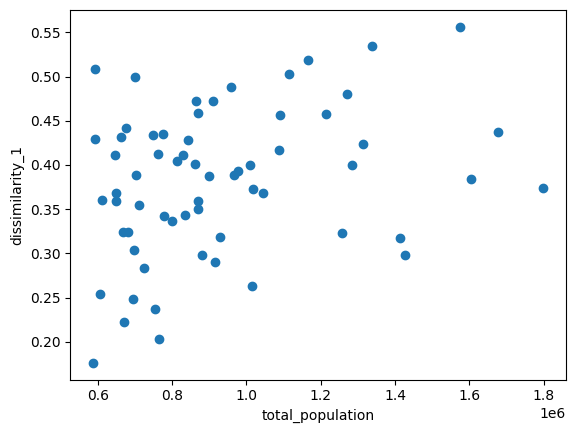

In [32]:
scores = ["edge_1", "half_edge_1", "moran_P", "dissimilarity_1"]

for score in scores:
    plotr("total_population", score, df = small_pop)

Fig 11

In [33]:
def rank_v_var(x_var, score_1, score_2, label_x = None, label_y = None, df = top_100):
    if label_x == None:
        label_x = x_var
    if label_y == None:
        label_y = label = f"{score_1} minus {score_2}"

    rank1 = df[[score_1, "cbsa_code"]].sort_values(score_1, ascending = False)
    rank2 = df[[score_2, "cbsa_code"]].sort_values(score_2, ascending = False)

    rank1 = rank1.reset_index(drop=True)
    rank1["rank_1"] = np.arange(1, len(rank1) + 1)

    rank2 = rank2.reset_index(drop=True)
    rank2["rank_2"] = np.arange(1, len(rank2) + 1)

    rank_df = rank1[["cbsa_code", "rank_1"]].merge(
        rank2[["cbsa_code", "rank_2"]],
        on="cbsa_code"
        ) 

    rank_df["rank_diff"] = rank_df["rank_1"] - rank_df["rank_2"]

    plot_df = df[["cbsa_code", x_var]].merge(
        rank_df[["cbsa_code", "rank_diff"]],
        on="cbsa_code"
        )

    plt.scatter(plot_df[x_var], plot_df["rank_diff"])

    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.show()

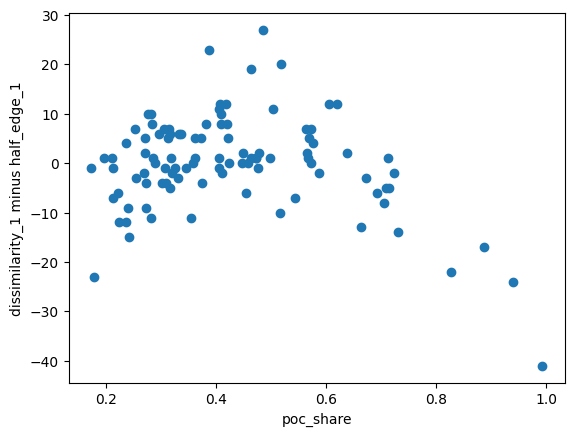

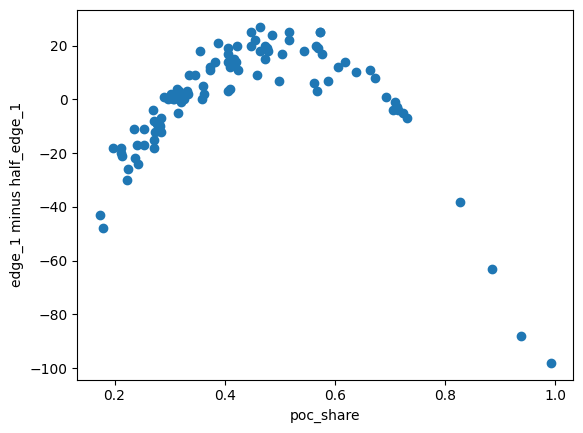

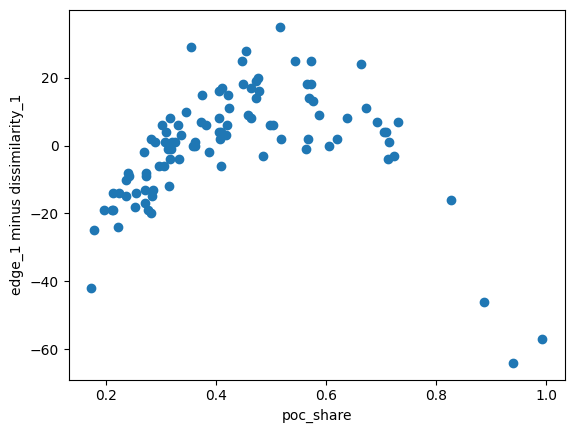

In [34]:
scores = [("dissimilarity_1", "half_edge_1"),
          ("edge_1", "half_edge_1"),
          ("edge_1", "dissimilarity_1")
    ]

for score in scores:
    rank_v_var("poc_share", score[0], score[1])
    #total x is the percentage minority

Fig 9

In [35]:
def multi_rankr(x_score, y_scores, color_dict, label_x=None,  best_fit=True, df=top_100):


    if label_x is None:
        label_x = x_score

    x = (
        df[[x_score, "cbsa_code"]]
        .sort_values(x_score)
        .reset_index(drop=True)
    )

    x["rank_x"] = np.arange(1, len(x) + 1)

    for y_col in y_scores:

        y_df = (
            df[[y_col, "cbsa_code"]]
            .sort_values(y_col)
            .reset_index(drop=True)
        )

        rank_col = f"rank_{y_col}"

        y_df[rank_col] = np.arange(1, len(y_df) + 1)

        ranks = x[["cbsa_code", "rank_x"]].merge(
            y_df[["cbsa_code", rank_col]],
            on="cbsa_code"
        )

        plt.scatter(
            ranks["rank_x"],
            ranks[rank_col],
            label=y_col,
            alpha=0.7,
            c = color_dict[y_col],
            s = 5
        )

    plt.xlabel(label_x)
    plt.ylabel("Ranks of Weighted Variants")
    plt.legend()
    plt.show()

In [36]:
weights_he = ["half_edge_0", 
        "half_edge_0.5", 
        "half_edge_2", 
        "half_edge_10", 
        "half_edge_lim"]

color_dict = {"half_edge_0" : "red", 
        "half_edge_0.5" : "orange", 
        "half_edge_2" : "limegreen", 
        "half_edge_10" : "blue", 
        "half_edge_lim" : "black"
        }


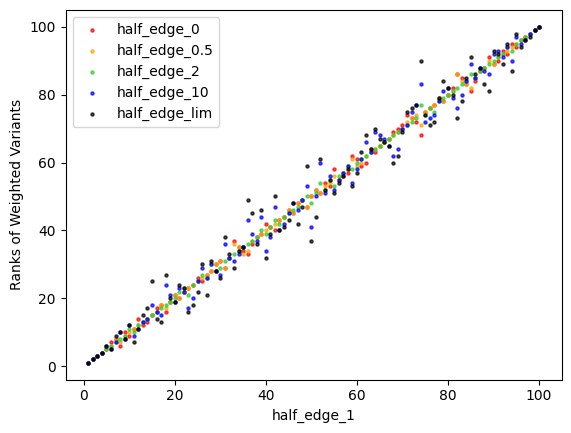

In [37]:
multi_rankr("half_edge_1", weights_he, color_dict)

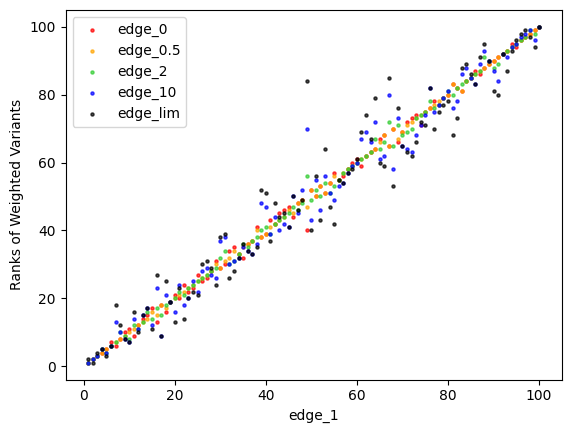

In [38]:
weights_e = ["edge_0", 
        "edge_0.5", 
        "edge_2", 
        "edge_10", 
        "edge_lim"]

color_dict = {"edge_0" : "red", 
        "edge_0.5" : "orange", 
        "edge_2" : "limegreen", 
        "edge_10" : "blue", 
        "edge_lim" : "black"
        }


multi_rankr("edge_1", weights_e, color_dict)